In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/marushkafernandes/store-sales-time-series-forecasting/oil.csv
/kaggle/input/datasets/marushkafernandes/store-sales-time-series-forecasting/sample_submission.csv
/kaggle/input/datasets/marushkafernandes/store-sales-time-series-forecasting/holidays_events.csv
/kaggle/input/datasets/marushkafernandes/store-sales-time-series-forecasting/stores.csv
/kaggle/input/datasets/marushkafernandes/store-sales-time-series-forecasting/train.csv
/kaggle/input/datasets/marushkafernandes/store-sales-time-series-forecasting/test.csv
/kaggle/input/datasets/marushkafernandes/store-sales-time-series-forecasting/transactions.csv


# STORES SALES PREDICTION USING TIME SERIES ML

Predict store sales in different stores using diff item categories

In [2]:
!pip install pandas numpy torch scikit-learn matplotlib

In [3]:
# Look at training data
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/marushkafernandes/store-sales-time-series-forecasting/train.csv')

In [4]:
df

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.000,0
1,1,2013-01-01,1,BABY CARE,0.000,0
2,2,2013-01-01,1,BEAUTY,0.000,0
3,3,2013-01-01,1,BEVERAGES,0.000,0
4,4,2013-01-01,1,BOOKS,0.000,0
...,...,...,...,...,...,...
3000883,3000883,2017-08-15,9,POULTRY,438.133,0
3000884,3000884,2017-08-15,9,PREPARED FOODS,154.553,1
3000885,3000885,2017-08-15,9,PRODUCE,2419.729,148
3000886,3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8


In [5]:
# What we want to predict: For every store, for every family or category we want 16 days of prediction

# X input channels with 120 data points each-> X output channels with 16 data points each

# Check diff values we have for family/category

len(df.family.unique())

33

In [6]:
# Check diff vals we have for store number
len(df.store_nbr.unique())

# No. of channels = len(df.family.unique()) * len(df.store_nbr.unique()) => no. of time series we have to make pred for = 1782 cols

54

In [7]:
# Pivot gives - index (date), cols (store nbr and family), vals (sales)

# First combine info of family and store number into store_family column
df['store_family'] = df.apply(lambda x: f"{x['store_nbr']}_{x['family']}", axis = 1)

In [8]:
df.head()  # print first five cols

,id,date,store_nbr,family,sales,onpromotion,store_family
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,1_AUTOMOTIVE
1,1,2013-01-01,1,BABY CARE,0.0,0,1_BABY CARE
2,2,2013-01-01,1,BEAUTY,0.0,0,1_BEAUTY
3,3,2013-01-01,1,BEVERAGES,0.0,0,1_BEVERAGES
4,4,2013-01-01,1,BOOKS,0.0,0,1_BOOKS


In [9]:
# For every date to occur single time, and all vals are as columns
df_pivoted = df.pivot(index = 'date', columns = 'store_family', values = 'sales')

In [10]:
df_pivoted

store_family,10_AUTOMOTIVE,10_BABY CARE,10_BEAUTY,10_BEVERAGES,10_BOOKS,10_BREAD/BAKERY,10_CELEBRATION,10_CLEANING,10_DAIRY,10_DELI,...,9_MAGAZINES,9_MEATS,9_PERSONAL CARE,9_PET SUPPLIES,9_PLAYERS AND ELECTRONICS,9_POULTRY,9_PREPARED FOODS,9_PRODUCE,9_SCHOOL AND OFFICE SUPPLIES,9_SEAFOOD
date,,,,,,,,,,,,,,,,,,,,,
2013-01-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000,0.0,0.0,0.0,0.000,0.00000,0.000,0.0,0.000000
2013-01-02,3.0,0.0,6.0,396.0,0.0,151.0,0.0,1110.0,101.0,276.0,...,0.0,374.531,482.0,0.0,0.0,651.292,83.00000,0.000,0.0,29.214000
2013-01-03,2.0,0.0,3.0,399.0,0.0,129.0,0.0,970.0,113.0,269.0,...,0.0,400.863,372.0,0.0,0.0,509.496,66.00000,0.000,0.0,25.000000
2013-01-04,2.0,0.0,4.0,460.0,0.0,105.0,0.0,669.0,66.0,92.0,...,0.0,310.878,324.0,0.0,0.0,332.672,57.00000,0.000,0.0,11.000000
2013-01-05,0.0,0.0,3.0,624.0,0.0,112.0,0.0,1093.0,88.0,194.0,...,0.0,447.685,461.0,0.0,0.0,510.919,84.00000,0.000,0.0,28.361000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-08-11,2.0,0.0,2.0,1459.0,0.0,76.0,5.0,532.0,251.0,269.0,...,5.0,309.245,373.0,11.0,2.0,525.224,112.10000,1453.078,140.0,23.831000
2017-08-12,2.0,0.0,3.0,1332.0,0.0,113.0,5.0,676.0,255.0,276.0,...,2.0,260.298,400.0,7.0,10.0,383.387,129.90399,1419.264,138.0,16.859001
2017-08-13,0.0,0.0,5.0,1526.0,0.0,119.0,6.0,670.0,270.0,251.0,...,3.0,327.206,510.0,2.0,9.0,412.458,105.16900,1693.607,200.0,20.000000


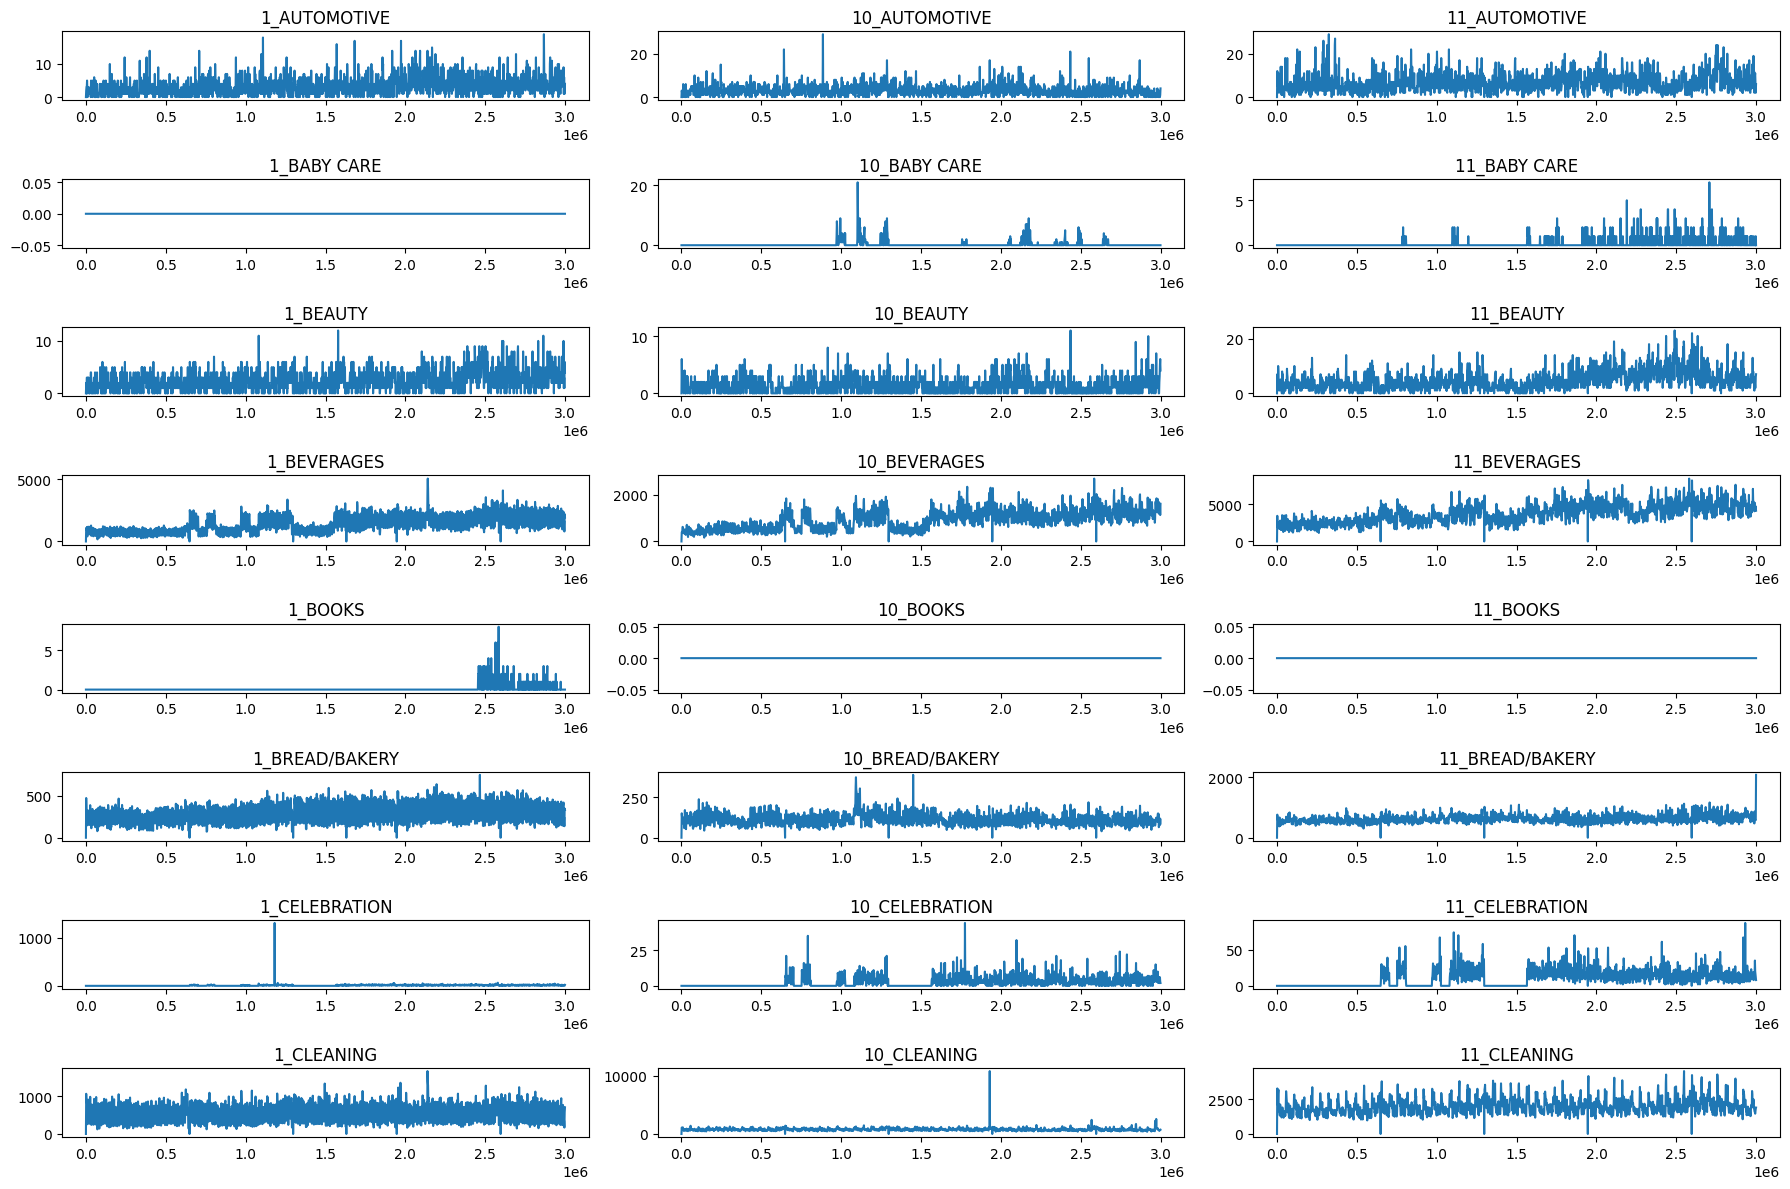

In [11]:
# Visualize the time series data
import matplotlib.pyplot as plt

fig, axs = plt.subplots(8, 3, figsize = (18, 12)) # we want to hv 8x3 grid where rows are families, and cols are store nos
# we want to see first 24 pieces- 8 diff categories and 3 diff stores to see sales

for i in range(8):
    for j in range(3):
        ax = axs[i][j] # i is family, j is store number
        ax.plot(df[(df.family == df.family.unique()[i]) & (df.store_nbr == df.store_nbr.unique()[j])].sales) # choose a unique fam and store : plot sales
        ax.set_title(f'{df.store_nbr.unique()[j]}_{df.family.unique()[i]}')
plt.tight_layout()

### DATA PREPROCESSING

In [12]:
# Scale the data cos nns is sensitive to scale i.e, features with large scale may be interpreted as more imp to nn
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

'''
NOTE: test data is unlabelled so we cant use for evaluation: so split train data into training and testing for eval.
Then we later use the entire training set to train the model and finally test on the unlabelled test set
'''

train_size = int(0.8 * len(df_pivoted)) # size of training data is 80 percent
train_data = df_pivoted.iloc[:train_size] # note we dont shuffle cos we normally use past data for training & future data for preds for time series data
test_data = df_pivoted.iloc[train_size:]

train_data_scaled = scaler.fit_transform(train_data) # learns the scale, and applies scale to train data
test_data_scaled = scaler.transform(test_data) # only do transform cos we're not going to learn scale again on test data (we use learned scaling from train data)
# in reality we cant scale unseen data

In [13]:
# Convert into array for training using helper function defined below

def create_X_y (data, input_length, output_length): 
    # i/p len: how much data we want to look at, o/p len: how many days we want to predict
    X,y = [], []

    for i in range(len(data) - input_length - output_length + 1): # +1 => we want to go up until last element
        # Eg: check if enough i/p data to make preds: look at 120 instances, predict 16 instances w/ ground truth (total 136 instances needed- to evaluate on)
        X.append (data[i: i + input_length]) # 120 days of data
        y.append(data[i + input_length: i + input_length + output_length]) # 16 days after that 120 days

    return np.array(X), np.array(y)

In [14]:
X_train, y_train = create_X_y(train_data_scaled, 120, 16)
X_test, y_test = create_X_y(test_data_scaled, 120, 16)

In [15]:
# we have 1212 instances, where we look at 120 days of data w/ each day having 1782 time series channels
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(1212, 120, 1782) (1212, 16, 1782)
(202, 120, 1782) (202, 16, 1782)


In [16]:
import torch

print(torch.cuda.is_available())  # Should return True

# Convert to torch compatible format 

X_train_tensor = torch.FloatTensor(X_train).cuda()
X_test_tensor = torch.FloatTensor(X_test).cuda()
y_train_tensor = torch.FloatTensor(y_train).cuda()
y_test_tensor = torch.FloatTensor(y_test).cuda()

True


In [17]:
from torch.utils.data import TensorDataset,DataLoader

# Create data loaders based on training and testing dataset

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True) # shuffle for variety

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size = 32, shuffle = False) # no use shuffling for inference

### BUILDING AND TRAINING MODEL

In [18]:
import torch.nn as nn
import torch.nn.functional as F

# Temporal CNN model
class TCNModel(nn.Module):
    def __init__(self):
        super().__init__()

        '''
        For conv1 i/p is unique families * unique store numbers, o/p is ur choice, kernel to extract feature imp maps, 
        padding is to retain i/p dims, dilation means the kernel is 3x3 but not dense- spreading the kernel: hence increase
        window of data to make predictions- so longer time frames can be taken into consideration

        Incrementally, increase dilation and padding always

        With convolutions, you dont have to do things one after another (u can do in parallel) i.e., in temporal order 
        unlike in LSTM, GRU where you have temporal dependence
        '''
        self.conv1 = nn.Conv1d(33*54, 64, kernel_size = 3, padding = 2, dilation = 1)
        self.conv2 = nn.Conv1d(64, 64, kernel_size = 3, padding = 4, dilation = 2)
        self.conv3 = nn.Conv1d(64, 64, kernel_size = 3, padding = 8, dilation = 4)

        self.fc = nn.Linear(64, 16*33*54) # o/p is 16 days of 33*54 or 17782 channels of data

    def forward(self, x):
        x = x.transpose(1, 2) # swap second and third dim 
        x = F.relu(self.conv1(x[:,:,:-2])) # break linearity, get rid of padding to get same temporal len as beginning
        x = F.relu(self.conv2(x[:,:,:-4]))
        x = F.relu(self.conv3(x[:,:,:-8]))

        return self.fc(x[:,:,-1]).view(-1, 16, 33*54) 
        # -1 means last val, view- get into format we want again: here, -1 (batch size inferred automatically), 16 days, 33*54 channels 

In [19]:
model = TCNModel().cuda()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)
criterion = nn.MSELoss() # Loss function - mean squared error 

In [20]:
# Training logic

for epoch in range(30):
    model.train() # put model in training mode
    epoch_loss = 0 # keep track of epoch loss

    for X_batch, y_batch, in train_loader:
        optimizer.zero_grad()  # reset gradients to zero

        y_pred = model(X_batch) # find prediction for model on i/p

        loss = torch.sqrt(criterion(y_pred, y_batch)) # compare preds w/ gnd truth
        loss.backward() # backpropagate loss

        optimizer.step() # take step w/ optimizer in right direction

        epoch_loss += loss.item()

    if (epoch+1) % 5 == 0:
        print(f'Epoch {epoch+1}, Loss: {epoch_loss/len(train_loader)}')

Epoch 5, Loss: 0.7878478185126656
Epoch 10, Loss: 0.738431105488225
Epoch 15, Loss: 0.7180640603366651
Epoch 20, Loss: 0.7040374545674575
Epoch 25, Loss: 0.695777344076257
Epoch 30, Loss: 0.6900063486475694


In [21]:
# Set model in evaluation mode or remaining training data

model.eval()

with torch.no_grad(): # since we're doing evaluation
    test_pred = model(X_test_tensor)
    test_loss = torch.sqrt(criterion(test_pred, y_test_tensor)) 
    print(test_loss)

tensor(172.2749, device='cuda:0')


### FULL DATASET TRAINING

In [22]:
full_data_scaled = scaler.fit_transform(df_pivoted)

X_full, y_full = create_X_y(full_data_scaled, 120, 16)

X_full_tensor = torch.FloatTensor(X_full).cuda()
y_full_tensor = torch.FloatTensor(y_full).cuda()

full_dataset = TensorDataset(X_full_tensor, y_full_tensor)
full_loader = DataLoader(full_dataset, batch_size = 32, shuffle = True)

final_model = TCNModel().cuda()
optimizer = torch.optim.Adam(final_model.parameters(), lr = 0.001)
criterion = nn.MSELoss()

In [23]:
# Training the final model

for epoch in range(30):
    final_model.train()
    epoch_loss = 0

    for X_batch, y_batch, in full_loader:
        optimizer.zero_grad()

        y_pred = final_model(X_batch)

        loss = torch.sqrt(criterion(y_pred, y_batch))
        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    if (epoch+1) % 5 == 0:
        print(f'Epoch {epoch+1}, Loss: {epoch_loss/len(full_loader)}')

Epoch 5, Loss: 0.7911977025927329
Epoch 10, Loss: 0.747193478808111
Epoch 15, Loss: 0.7271363698706335
Epoch 20, Loss: 0.7169151439958689
Epoch 25, Loss: 0.7083353436723048
Epoch 30, Loss: 0.701335400951152


In [24]:
# Apply this model onto our test csv file
final_model.eval()

with torch.no_grad():
     # get last 120 days of data from training data and do prediction on that for first 16 days of test data, also add extra dim
    last_sequence = torch.FloatTensor(full_data_scaled[-120:]).unsqueeze(0).cuda()
    predictions = final_model(last_sequence)

In [25]:
predictions

tensor([[[-0.5022, -0.4686,  0.5279,  ...,  0.3094,  0.5853,  0.0247],
         [-0.6201, -0.4509,  0.3967,  ...,  0.1897,  0.9167,  0.2187],
         [-0.6590, -0.5709,  0.3726,  ...,  0.1152,  0.8903, -0.1212],
         ...,
         [-0.5422, -0.4486,  0.7201,  ...,  1.1318,  2.3324,  0.0637],
         [-0.5096, -0.3865,  0.6576,  ...,  0.5173,  2.3754,  0.2880],
         [-0.4546, -0.3862,  0.5289,  ...,  0.4125,  2.3404,  0.2473]]],
       device='cuda:0')

In [26]:
predictions = predictions.cpu().numpy().squeeze(0) # remove additional dim
predictions = scaler.inverse_transform(predictions) # get rid of vals not actual sales
predictions = np.maximum(predictions, 0) # remove negative vals cos cant be sales

In [27]:
predictions

array([[1.7498652e+00, 0.0000000e+00, 2.1157107e+00, ..., 1.2414525e+03,
        1.9094700e+01, 1.7116287e+01],
       [1.4367914e+00, 0.0000000e+00, 1.9311259e+00, ..., 1.1361136e+03,
        2.6477964e+01, 1.8934977e+01],
       [1.3334125e+00, 0.0000000e+00, 1.8971481e+00, ..., 1.0705031e+03,
        2.5889313e+01, 1.5748027e+01],
       ...,
       [1.6436057e+00, 0.0000000e+00, 2.3860450e+00, ..., 1.9652959e+03,
        5.8026657e+01, 1.7481634e+01],
       [1.7300951e+00, 0.0000000e+00, 2.2982254e+00, ..., 1.4244904e+03,
        5.8984035e+01, 1.9584896e+01],
       [1.8761330e+00, 0.0000000e+00, 2.1170464e+00, ..., 1.3321729e+03,
        5.8204121e+01, 1.9203182e+01]], dtype=float32)

In [28]:
# Read test data

test_df = pd.read_csv('/kaggle/input/datasets/marushkafernandes/store-sales-time-series-forecasting/test.csv')

In [29]:
test_df

,id,date,store_nbr,family,onpromotion
0,3000888,2017-08-16,1,AUTOMOTIVE,0
1,3000889,2017-08-16,1,BABY CARE,0
2,3000890,2017-08-16,1,BEAUTY,2
3,3000891,2017-08-16,1,BEVERAGES,20
4,3000892,2017-08-16,1,BOOKS,0
...,...,...,...,...,...
28507,3029395,2017-08-31,9,POULTRY,1
28508,3029396,2017-08-31,9,PREPARED FOODS,0
28509,3029397,2017-08-31,9,PRODUCE,1
28510,3029398,2017-08-31,9,SCHOOL AND OFFICE SUPPLIES,9


In [30]:
# combine store and family together in test data

test_df['store_family'] = test_df.apply(lambda x: f"{x['store_nbr']}_{x['family']}", axis = 1)

In [31]:
test_df

,id,date,store_nbr,family,onpromotion,store_family
0,3000888,2017-08-16,1,AUTOMOTIVE,0,1_AUTOMOTIVE
1,3000889,2017-08-16,1,BABY CARE,0,1_BABY CARE
2,3000890,2017-08-16,1,BEAUTY,2,1_BEAUTY
3,3000891,2017-08-16,1,BEVERAGES,20,1_BEVERAGES
4,3000892,2017-08-16,1,BOOKS,0,1_BOOKS
...,...,...,...,...,...,...
28507,3029395,2017-08-31,9,POULTRY,1,9_POULTRY
28508,3029396,2017-08-31,9,PREPARED FOODS,0,9_PREPARED FOODS
28509,3029397,2017-08-31,9,PRODUCE,1,9_PRODUCE
28510,3029398,2017-08-31,9,SCHOOL AND OFFICE SUPPLIES,9,9_SCHOOL AND OFFICE SUPPLIES


In [32]:
# Sort unique dates
dates = sorted(test_df['date'].unique())

In [33]:
# Make prediction data frame
pred_df = pd.DataFrame(predictions, index = dates, columns = df_pivoted.columns)

In [34]:
pred_df

store_family,10_AUTOMOTIVE,10_BABY CARE,10_BEAUTY,10_BEVERAGES,10_BOOKS,10_BREAD/BAKERY,10_CELEBRATION,10_CLEANING,10_DAIRY,10_DELI,...,9_MAGAZINES,9_MEATS,9_PERSONAL CARE,9_PET SUPPLIES,9_PLAYERS AND ELECTRONICS,9_POULTRY,9_PREPARED FOODS,9_PRODUCE,9_SCHOOL AND OFFICE SUPPLIES,9_SEAFOOD
2017-08-16,1.749865,0.000000,2.115711,1023.522583,0.029090,92.390427,3.308542,800.125061,300.125977,209.277893,...,3.316370,337.504547,360.015442,6.558403,6.110857,358.983429,95.076889,1241.452515,19.094700,17.116287
2017-08-17,1.436791,0.000000,1.931126,942.974976,0.015976,88.911736,4.047768,732.131165,227.643005,214.195740,...,2.887553,453.343628,344.742615,5.990223,7.066114,390.861969,102.605949,1136.113647,26.477964,18.934977
2017-08-18,1.333413,0.000000,1.897148,968.041260,0.000000,78.422157,3.322783,758.988037,213.154144,223.332626,...,3.212337,268.344116,284.526367,5.419560,4.928057,373.123291,87.519318,1070.503052,25.889313,15.748027
2017-08-19,2.646951,0.008331,2.644257,1431.954590,0.000000,115.060135,7.102407,1047.009155,358.589508,287.131042,...,4.547475,388.503326,549.490479,9.092405,10.900704,585.979675,134.534424,1839.795410,29.344784,25.736727
2017-08-20,3.348825,0.078016,2.736475,1498.327026,0.000000,138.316833,4.216617,989.891907,392.964233,299.589142,...,4.736221,425.503143,573.350769,9.901492,12.298217,578.498474,133.739258,2032.816650,33.861916,26.245066
2017-08-21,2.101840,0.000000,2.161914,1158.406128,0.000000,105.589447,1.694983,751.127869,294.050415,225.288254,...,2.414390,382.297943,397.825317,6.528202,6.825477,381.639313,92.960251,1418.286743,30.210888,17.428631
2017-08-22,1.428083,0.000000,2.162896,1144.246460,0.026602,97.202286,2.576116,859.347595,290.845306,233.644211,...,2.013700,319.610443,391.947540,6.913976,5.352141,380.057220,95.934036,1933.685669,34.871689,14.364128
2017-08-23,0.971149,0.000000,2.152313,1137.375977,0.000000,100.143425,3.377341,821.709290,320.456421,247.252960,...,2.525245,356.046783,417.410950,6.980196,8.227780,376.900238,107.281212,1346.755005,36.985779,18.280020
2017-08-24,1.776646,0.000000,1.985374,1159.751221,0.014360,99.827324,2.590472,753.096741,271.257141,248.494827,...,1.928429,489.601227,398.353394,7.712663,6.909507,439.188080,101.523628,1348.297729,41.566330,19.148520
2017-08-25,1.673091,0.000000,1.886434,1104.160889,0.004255,85.007492,3.311875,773.137634,232.107666,262.353607,...,2.774023,293.260376,370.693390,5.894542,4.698585,429.005341,94.815468,1060.984375,40.479000,15.210896


In [35]:
# Stack is the reverse operation of pivot
pred_long = pred_df.stack().reset_index() # to get structure in beginning
pred_long.columns = ['date', 'store_family', 'sales']

In [36]:
pred_long

,date,store_family,sales
0,2017-08-16,10_AUTOMOTIVE,1.749865
1,2017-08-16,10_BABY CARE,0.000000
2,2017-08-16,10_BEAUTY,2.115711
3,2017-08-16,10_BEVERAGES,1023.522583
4,2017-08-16,10_BOOKS,0.029090
...,...,...,...
28507,2017-08-31,9_POULTRY,419.590149
28508,2017-08-31,9_PREPARED FOODS,109.483383
28509,2017-08-31,9_PRODUCE,1332.172852
28510,2017-08-31,9_SCHOOL AND OFFICE SUPPLIES,58.204121


In [37]:
submission_df = test_df.merge(pred_long, on = ['date', 'store_family'], how = 'left')

In [38]:
submission_df[['id', 'sales']].to_csv('submission.csv', index = False)